# EvidenceRAG: A Research Assistant That Knows When It Doesn't Know

## Research Question

**Can evidence-aware retrieval improve the reliability of a multi-paper RAG assistant by reducing unsupported answers without excessively reducing its ability to answer supported questions?**

This notebook evaluates a Basic RAG baseline against EvidenceRAG, which adds an evidence-verification step before generating an answer.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"

QUESTIONS_FILE = EXPERIMENTS_DIR / "questions.json"
BASIC_RESULTS_FILE = EXPERIMENTS_DIR / "basic_rag_results.json"
EVIDENCE_RESULTS_FILE = EXPERIMENTS_DIR / "evidencerag_final_results.json"
RETRIEVAL_RESULTS_FILE = EXPERIMENTS_DIR / "retrieval_results.json"

print("Project root:", PROJECT_ROOT)
print("Experiments directory:", EXPERIMENTS_DIR)

Project root: c:\Jyothirmai\Plaksha MSAI\term 1\python programming - Raghav\labs\lab 6- capstone\evidencerag-1
Experiments directory: c:\Jyothirmai\Plaksha MSAI\term 1\python programming - Raghav\labs\lab 6- capstone\evidencerag-1\experiments


In [2]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


questions = load_json(QUESTIONS_FILE)
basic_results = load_json(BASIC_RESULTS_FILE)
evidence_results = load_json(EVIDENCE_RESULTS_FILE)
retrieval_results = load_json(RETRIEVAL_RESULTS_FILE)

print("Questions:", len(questions))
print("Basic RAG results:", len(basic_results))
print("EvidenceRAG results:", len(evidence_results))
print("Retrieval results:", len(retrieval_results))

Questions: 12
Basic RAG results: 12
EvidenceRAG results: 12
Retrieval results: 12


## Experimental Setup

The final experiment used the following configuration.

| Parameter | Value | Role |
|---|---|---|
| Research papers | 21 | Evaluation corpus |
| Total chunks | 1,149 | Retrieved evidence units |
| Chunk size | 400 words | Chunking choice |
| Chunk overlap | 80 words | Chunking choice |
| Embedding model | `all-MiniLM-L6-v2` | Semantic retrieval |
| Similarity metric | Cosine similarity | Required retrieval method |
| Top-k | 5 | Number of retrieved chunks |
| Generation model | `google/flan-t5-base` | Answer generation |
| Evidence verifier | `google/flan-t5-base` | Evidence verification |
| Evaluation questions | 12 | Evaluation set |
| Answerable questions | 10 | Supported by corpus |
| Unanswerable questions | 2 | Should be refused |

### Evidence decisions

EvidenceRAG assigns one of three decisions:

- **SUPPORTED** — sufficient evidence is available to answer.
- **INSUFFICIENT** — the corpus does not provide enough evidence.
- **CONFLICTING** — retrieved evidence contains conflicting information.

In [3]:
answerable = [q for q in questions if q["answerable"]]
unanswerable = [q for q in questions if not q["answerable"]]

print(f"Total questions: {len(questions)}")
print(f"Answerable questions: {len(answerable)}")
print(f"Unanswerable questions: {len(unanswerable)}")

print("\nQuestion types:")
question_types = {}

for q in questions:
    question_types[q["type"]] = question_types.get(q["type"], 0) + 1

for qtype, count in question_types.items():
    print(f"- {qtype}: {count}")

Total questions: 12
Answerable questions: 10
Unanswerable questions: 2

Question types:
- single_paper: 4
- multi_paper: 3
- comparison: 2
- unanswerable: 2
- ambiguous: 1


## Retrieval Evaluation

Retrieval was evaluated separately from generation.

For each answerable question, the expected source document was known in advance. Retrieval@5 is counted as successful when at least one expected source document appears among the five retrieved chunks.

This separates the question:

> "Did the system retrieve relevant evidence?"

from:

> "Did the generator produce a good answer?"

In [8]:
# Retrieval@5 evaluation

answerable_retrieval_results = [
    result for result in retrieval_results
    if result["answerable"]
]

retrieval_hits = sum(
    result["retrieval_hit"]
    for result in answerable_retrieval_results
)

retrieval_total = len(answerable_retrieval_results)

retrieval_at_5 = retrieval_hits / retrieval_total

print(f"Retrieval@5: {retrieval_at_5:.3f}")
print(f"Successful retrievals: {retrieval_hits}/{retrieval_total}")

Retrieval@5: 1.000
Successful retrievals: 10/10


## Basic RAG Baseline

The baseline uses the standard RAG pipeline:

**retrieve → generate**

It retrieves the top-5 chunks using the same retrieval setup as EvidenceRAG, but does not apply the evidence-verification gate before generating an answer.

The baseline is evaluated on the same 12 questions and uses the same answerability labels as EvidenceRAG. This makes the comparison fair because the main difference is the evidence-verification step.

In [9]:
# Basic RAG baseline evaluation

basic_unanswerable = [
    result for result in basic_results
    if not result["answerable"]
]

basic_unsupported = sum(
    bool(result["answer"].strip())
    for result in basic_unanswerable
)

basic_total_unanswerable = len(basic_unanswerable)

basic_unsupported_rate = (
    basic_unsupported / basic_total_unanswerable
)

print(
    f"Unsupported answers on unanswerable questions: "
    f"{basic_unsupported}/{basic_total_unanswerable}"
)

print(
    f"Unsupported-answer rate: "
    f"{basic_unsupported_rate:.1%}"
)

Unsupported answers on unanswerable questions: 2/2
Unsupported-answer rate: 100.0%


In [10]:
print("Basic RAG answers to the unanswerable questions:\n")

for result in basic_unanswerable:
    print(f"{result['id']}")
    print(f"Question: {result['question']}")
    print(f"Answer: {result['answer']}")
    print("-" * 70)

Basic RAG answers to the unanswerable questions:

Q10
Question: What does the corpus say about the best prompting strategy for predicting tomorrow's stock-market closing price?
Answer: 2022. Revisiting the gold standard: Grounding summarization evaluation with robust human evaluation.
----------------------------------------------------------------------
Q11
Question: Which hallucination detection method is definitively the most accurate method for every possible large language model and every task?
Answer: Detection Benchmarks.
----------------------------------------------------------------------


## Basic RAG vs EvidenceRAG

The central comparison is whether the evidence-verification step reduces unsupported answers.

EvidenceRAG has three possible evidence decisions:

- `SUPPORTED` → generate an answer
- `INSUFFICIENT` → refuse to answer
- `CONFLICTING` → answer while indicating that the evidence conflicts

The primary safety metric is the unsupported-answer rate on the two unanswerable questions.

## EvidenceRAG Evaluation

EvidenceRAG adds an evidence-verification gate between retrieval and generation.

For this evaluation:

- `SUPPORTED` → answer is generated.
- `INSUFFICIENT` → the system refuses.
- `CONFLICTING` → the system answers while marking the evidence as conflicting.

The evaluation measures both the safety benefit and the cost of being conservative.

In [12]:
# EvidenceRAG evaluation

evidence_answerable = [
    result for result in evidence_results
    if result["answerable"]
]

evidence_unanswerable = [
    result for result in evidence_results
    if not result["answerable"]
]

# Answerable questions allowed through
evidence_answered = sum(
    result["status"] in ["ANSWERED", "ANSWERED_WITH_CONFLICT"]
    for result in evidence_answerable
)

# False refusals on answerable questions
false_refusals = sum(
    result["status"] == "REFUSED"
    for result in evidence_answerable
)

# Correct refusals on unanswerable questions
correct_refusals = sum(
    result["status"] == "REFUSED"
    for result in evidence_unanswerable
)

# Unsupported answers on unanswerable questions
unsupported_unanswerable = sum(
    result["status"] != "REFUSED"
    for result in evidence_unanswerable
)

# Conflicting cases
conflicting_cases = sum(
    result["status"] == "ANSWERED_WITH_CONFLICT"
    for result in evidence_results
)

answerable_total = len(evidence_answerable)
unanswerable_total = len(evidence_unanswerable)

supported_question_coverage = evidence_answered / answerable_total
false_refusal_rate = false_refusals / answerable_total
correct_refusal_rate = correct_refusals / unanswerable_total
unsupported_answer_rate = unsupported_unanswerable / unanswerable_total

print(
    f"Answerable questions allowed: "
    f"{evidence_answered}/{answerable_total}"
)

print(
    f"Supported-question coverage: "
    f"{supported_question_coverage:.1%}"
)

print(
    f"Unanswerable questions correctly refused: "
    f"{correct_refusals}/{unanswerable_total}"
)

print(
    f"Correct refusal rate: "
    f"{correct_refusal_rate:.1%}"
)

print(
    f"False refusals on answerable questions: "
    f"{false_refusals}/{answerable_total}"
)

print(
    f"False-refusal rate: "
    f"{false_refusal_rate:.1%}"
)

print(
    f"Conflicting cases detected: "
    f"{conflicting_cases}"
)

print(
    f"Unsupported answers on unanswerable questions: "
    f"{unsupported_unanswerable}/{unanswerable_total}"
)

print(
    f"Unsupported-answer rate: "
    f"{unsupported_answer_rate:.1%}"
)

Answerable questions allowed: 8/10
Supported-question coverage: 80.0%
Unanswerable questions correctly refused: 2/2
Correct refusal rate: 100.0%
False refusals on answerable questions: 2/10
False-refusal rate: 20.0%
Conflicting cases detected: 1
Unsupported answers on unanswerable questions: 0/2
Unsupported-answer rate: 0.0%


## Main Result: Unsupported Answers on Unanswerable Questions

The primary safety result is the unsupported-answer rate on questions that are known to be unanswerable from the corpus.

A lower value is better.

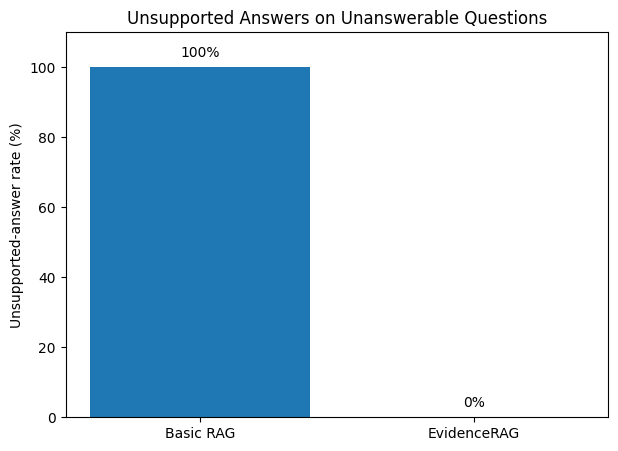

In [13]:
# Main comparison plot

systems = ["Basic RAG", "EvidenceRAG"]
unsupported_rates = [
    basic_unsupported_rate * 100,
    unsupported_answer_rate * 100
]

plt.figure(figsize=(7, 5))
plt.bar(systems, unsupported_rates)

plt.ylabel("Unsupported-answer rate (%)")
plt.title("Unsupported Answers on Unanswerable Questions")
plt.ylim(0, 110)

for i, value in enumerate(unsupported_rates):
    plt.text(i, value + 3, f"{value:.0f}%", ha="center")

plt.show()

## Retrieval Similarity and the Evidence Threshold

The initial evidence gate used the strongest retrieved-chunk similarity as a possible signal for whether a question could be answered.

A threshold sweep was performed from 0.35 to 0.75.

The important question was whether a single similarity threshold could separate answerable questions from unanswerable questions.

In [14]:
# Extract strongest similarity for every question

similarity_data = []

for result in evidence_results:
    similarity_data.append({
        "id": result["id"],
        "answerable": result["answerable"],
        "similarity": result["strongest_similarity"]
    })

for item in similarity_data:
    label = "Answerable" if item["answerable"] else "Unanswerable"
    print(
        f"{item['id']}: {label} | "
        f"similarity = {item['similarity']:.4f}"
    )

Q1: Answerable | similarity = 0.7494
Q2: Answerable | similarity = 0.4764
Q3: Answerable | similarity = 0.4372
Q4: Answerable | similarity = 0.4970
Q5: Answerable | similarity = 0.8014
Q6: Answerable | similarity = 0.7072
Q7: Answerable | similarity = 0.7665
Q8: Answerable | similarity = 0.6354
Q9: Answerable | similarity = 0.6726
Q10: Unanswerable | similarity = 0.3698
Q11: Unanswerable | similarity = 0.7097
Q12: Answerable | similarity = 0.7759


### A key example

Q6 is answerable and has a strongest similarity of approximately **0.7072**.

Q11 is deliberately unanswerable and has a strongest similarity of approximately **0.7097**.

Therefore, the unanswerable question has a slightly higher similarity score than an answerable question.

This demonstrates why retrieval similarity alone cannot be treated as proof that the corpus contains sufficient evidence.

In [16]:
# Compare Q6 and Q11 directly

for question_id in ["Q6", "Q11"]:
    result = next(
        r for r in evidence_results
        if r["id"] == question_id
    )

    label = "Answerable" if result["answerable"] else "Unanswerable"

    print(
        f"{question_id}: {label} | "
        f"strongest similarity = "
        f"{result['strongest_similarity']:.4f}"
    )

Q6: Answerable | strongest similarity = 0.7072
Q11: Unanswerable | strongest similarity = 0.7097


## Similarity Threshold Sweep

I tested different similarity thresholds to determine whether a simple retrieval-score gate could provide reliable evidence control.

The experiment revealed a trade-off: lower thresholds allowed more answerable questions through but failed to reject unsupported questions, while higher thresholds rejected more unsupported questions but also rejected answerable questions.

No single threshold provided a clean separation.

In [17]:
# Results from the similarity-threshold experiment

thresholds = [
    0.35, 0.40, 0.45, 0.50,
    0.55, 0.60, 0.65, 0.70, 0.75
]

answerable_allowed = [
    10, 10, 9, 7,
    7, 7, 6, 5, 3
]

unanswerable_blocked = [
    0, 1, 1, 1,
    1, 1, 1, 1, 2
]

answerable_coverage = [
    value / 10 * 100
    for value in answerable_allowed
]

unanswerable_refusal_rate = [
    value / 2 * 100
    for value in unanswerable_blocked
]

print("Threshold | Answerable coverage | Unanswerable refusal")
print("-" * 55)

for t, coverage, refusal in zip(
    thresholds,
    answerable_coverage,
    unanswerable_refusal_rate
):
    print(
        f"{t:.2f}      | "
        f"{coverage:5.1f}%              | "
        f"{refusal:5.1f}%"
    )

Threshold | Answerable coverage | Unanswerable refusal
-------------------------------------------------------
0.35      | 100.0%              |   0.0%
0.40      | 100.0%              |  50.0%
0.45      |  90.0%              |  50.0%
0.50      |  70.0%              |  50.0%
0.55      |  70.0%              |  50.0%
0.60      |  70.0%              |  50.0%
0.65      |  60.0%              |  50.0%
0.70      |  50.0%              |  50.0%
0.75      |  30.0%              | 100.0%


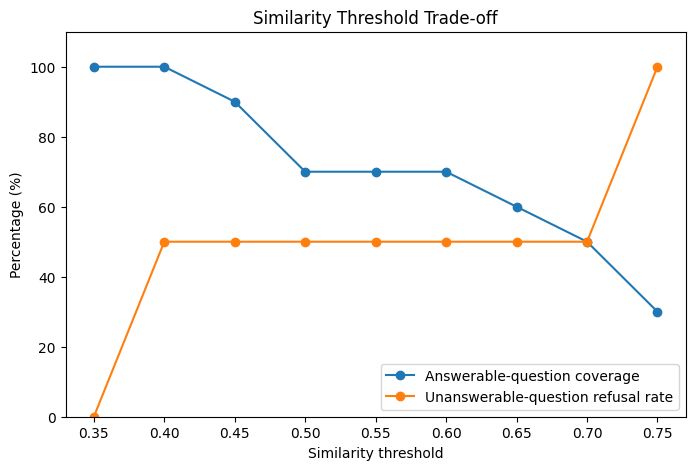

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    answerable_coverage,
    marker="o",
    label="Answerable-question coverage"
)

plt.plot(
    thresholds,
    unanswerable_refusal_rate,
    marker="o",
    label="Unanswerable-question refusal rate"
)

plt.xlabel("Similarity threshold")
plt.ylabel("Percentage (%)")
plt.title("Similarity Threshold Trade-off")
plt.ylim(0, 110)
plt.legend()

plt.show()

## Error Analysis

The aggregate metrics do not tell the complete story. Examining individual questions shows where EvidenceRAG improves reliability and where it becomes too conservative.

The most important cases are Q10 and Q11, which are deliberately unanswerable, and Q5 and Q9, which are answerable but were incorrectly refused.

In [19]:
# Inspect important cases

important_ids = ["Q5", "Q9", "Q10", "Q11"]

for question_id in important_ids:
    basic = next(
        r for r in basic_results
        if r["id"] == question_id
    )

    evidence = next(
        r for r in evidence_results
        if r["id"] == question_id
    )

    print("=" * 80)
    print(question_id)
    print("Question:", evidence["question"])
    print("Ground-truth answerable:", evidence["answerable"])
    print("Strongest similarity:", round(
        evidence["strongest_similarity"], 4
    ))
    print("Basic RAG:", basic["answer"])
    print("EvidenceRAG status:", evidence["status"])
    print("EvidenceRAG:", evidence["answer"])

Q5
Question: What are some major categories of hallucination discussed in research on large language models?
Ground-truth answerable: True
Strongest similarity: 0.8014
Basic RAG: 2023.
EvidenceRAG status: REFUSED
EvidenceRAG: I do not have enough evidence in the provided research corpus to answer this question reliably.
Q9
Question: How does FactScore differ from factual consistency evaluation methods developed for abstractive summarization?
Ground-truth answerable: True
Strongest similarity: 0.6726
Basic RAG: QG-QA and NLI-based methods show better performance than other approaches, especially when combined together.
EvidenceRAG status: REFUSED
EvidenceRAG: I do not have enough evidence in the provided research corpus to answer this question reliably.
Q10
Question: What does the corpus say about the best prompting strategy for predicting tomorrow's stock-market closing price?
Ground-truth answerable: False
Strongest similarity: 0.3698
Basic RAG: 2022. Revisiting the gold standard: Gro

### Q11: High similarity but insufficient evidence

Q11 asks:

> Which hallucination detection method is definitively the most accurate method for every possible large language model and every task?

The question is deliberately unanswerable from the corpus because it asks for a universal claim.

However, its strongest retrieval similarity is **0.7097**, which is higher than the **0.7072** observed for answerable Q6.

Basic RAG generated the unsupported answer:

> `Detection Benchmarks.`

EvidenceRAG classified the evidence as `INSUFFICIENT` and refused to answer.

This is an important result because it shows that **high semantic similarity does not necessarily mean sufficient evidence**.

## Decisions and Negative Results

Several approaches were tested before the final configuration was retained. The unsuccessful experiments are included because they influenced the final design.

### 1. Similarity-threshold tuning

A threshold sweep from 0.35 to 0.75 did not produce a clean separation between answerable and unanswerable questions. Lower thresholds allowed more answerable questions through but failed to reject all unanswerable questions; higher thresholds became increasingly conservative.

**Decision:** Do not rely on a single similarity threshold as the evidence decision.

### 2. Question-type-aware verifier

A second verifier experiment included the question type in the verification prompt.

This did not improve reliability. The experimental version incorrectly allowed Q10 and Q11, the two deliberately unanswerable questions, to pass through.

**Decision:** Retain the original verifier rather than the question-type-aware version.

### 3. Reference-aware retrieval

A reference-aware retrieval experiment attempted to detect bibliography/reference chunks and penalize them during retrieval.

The detector was too conservative and failed to reliably identify obvious reference entries in the extracted PDF text.

**Decision:** Do not claim this intervention as an improvement. It is retained as a negative result.

### Final design decision

The final system therefore uses the original evidence verifier with the labels `SUPPORTED`, `INSUFFICIENT`, and `CONFLICTING`. The experiment prioritizes reducing unsupported answers while explicitly measuring the cost of false refusals.

## Final Results

| Metric | Result |
|---|---:|
| Retrieval@5 on answerable questions | **100% (10/10)** |
| Basic RAG unsupported-answer rate | **100% (2/2)** |
| EvidenceRAG unsupported-answer rate | **0% (0/2)** |
| EvidenceRAG correct refusal rate | **100% (2/2)** |
| EvidenceRAG answerable-question coverage | **80% (8/10)** |
| EvidenceRAG false-refusal rate | **20% (2/10)** |
| Conflicting cases detected | **1** |

The headline result is that EvidenceRAG reduced unsupported answers on the two unanswerable questions from **100% to 0%**, but this safety improvement came with a **20% false-refusal rate** on answerable questions.

## Conclusion

EvidenceRAG demonstrated that an evidence-verification step can make a multi-paper RAG system more cautious about unsupported questions.

On the evaluation set, Basic RAG produced unsupported answers for both deliberately unanswerable questions, while EvidenceRAG correctly refused both. However, EvidenceRAG also refused two answerable questions, showing that the verifier is conservative on more complex multi-paper and comparison questions.

The main lesson is that **retrieval quality and evidence sufficiency are different problems**. Retrieval@5 reached 100%, but high retrieval similarity alone could not distinguish an answerable question from an unanswerable one.

With more time, I would move from question-level verification to claim-level verification, especially for multi-paper synthesis and comparison questions.